<a href="https://colab.research.google.com/github/AyseNil-star/AyseNil-star/blob/main/labs/W1_HeartDisease_Workflow_and_First_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 — Heart Disease: workflow, claims, and first EDA

### Learning goals
- Load the UCI Heart Disease (Cleveland) dataset
- Create a binary target (`disease`)
- Do first-pass checks: shape, dtypes, missingness
- Make 2 starter plots and write 2 evidence-based observations

### Critical thinking prompt
Before you analyze: **What is the claim** you want to test, and **what would count as evidence**?

**Deliverable:** 5-line project pitch (question, hypothesis, outcome, 2 predictors, 1 bias risk)


In [1]:
# Core imports (kept minimal for beginners)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

# Dataset URL (UCI Heart Disease - Cleveland)
UCI_URL = "https://www.archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Column names for processed.cleveland.data (14 columns commonly used in teaching)
COLS = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach",
        "exang","oldpeak","slope","ca","thal","num"]


In [2]:
import ssl
import io
import urllib.request # Added this import

def load_raw():
    # Create an unverified SSL context to bypass certificate verification
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE

    # Open the URL with the unverified context
    with urllib.request.urlopen(UCI_URL, context=ctx) as url_response:
        # Read the content and decode it
        s = url_response.read().decode('utf-8')

    # Use io.StringIO to make the string behave like a file for pandas.read_csv
    df_raw = pd.read_csv(io.StringIO(s), header=None, names=COLS)
    return df_raw

def coerce_types(df_raw):
    # Missing values are sometimes encoded as "?"
    df = df_raw.replace("?", np.nan).copy()

    # Convert numeric-looking columns
    numeric_cols = ["age","trestbps","chol","thalach","oldpeak","ca","thal","num"]
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Binary target: disease present if num > 0 (UCI convention)
    df["disease"] = (df["num"] > 0).astype("Int64")
    return df

df_raw = load_raw()
df = coerce_types(df_raw)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,disease
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0


In [3]:
def quick_profile(df):
    """Small, beginner-friendly dataframe profile."""
    display(df.head())
    print("\nShape:", df.shape)
    print("\nDtypes:")
    print(df.dtypes)
    print("\nMissingness (top 10):")
    miss = df.isna().mean().sort_values(ascending=False)
    display(miss.head(10).to_frame("missing_fraction"))
    print("\nBasic describe (numeric):")
    display(df.describe(include=[np.number]).T)

def check_columns(df):
    assert df.columns.is_unique, "Duplicate column names found"
    assert df.shape[0] > 0, "No rows loaded"
    return True


In [4]:
check_columns(df)
quick_profile(df)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,disease
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0



Shape: (303, 15)

Dtypes:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
num           int64
disease       Int64
dtype: object

Missingness (top 10):


,missing_fraction
ca,0.013201
thal,0.006601
age,0.000000
trestbps,0.000000
chol,0.000000
sex,0.000000
cp,0.000000
restecg,0.000000
fbs,0.000000
thalach,0.000000



Basic describe (numeric):


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## TODO 1 — Understand the variables
Fill in (in your own words):
- `age` measures: Ages of patient
- `sex` is coded as: gender as 1=male, 0=female
- `cp` (chest pain type) likely means: A categorical ranking of pain severity or types 1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic.  num= is the original "goal" variable (the diameter narrowing of vein; if num is 0, disease is 0 no disease; if num is 1–4, disease is 1 presence of disease.
- `num` and `disease` relationship is:

**What could be biased in this dataset?** (sample selection? measurement?)
Although there is youth age as min but 25% is 48 age. Table does not show reliable fluctuation in terms of age. Also only 25% people are women and again it does not represent reliable graph.

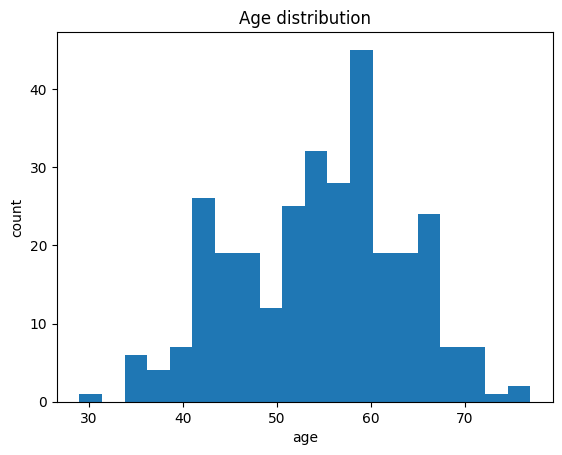

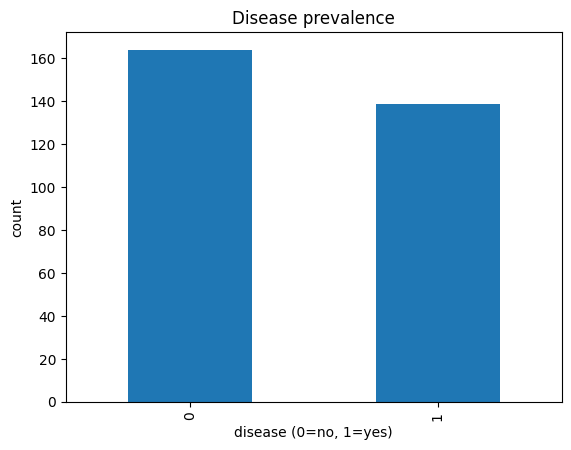

In [5]:
# Starter plot 1: age distribution
plt.figure()
df["age"].dropna().plot(kind="hist", bins=20)
plt.xlabel("age")
plt.ylabel("count")
plt.title("Age distribution")
plt.show()

# Starter plot 2: disease prevalence
plt.figure()
df["disease"].value_counts(dropna=False).sort_index().plot(kind="bar")
plt.xlabel("disease (0=no, 1=yes)")
plt.ylabel("count")
plt.title("Disease prevalence")
plt.show()


## TODO 2 — Write two observations (complete sentences)
1) Observation from age distribution: This may represent that the heart disease are mostly problem for eldery and but also younger people have a early risk to have disease. In this data number of younder is fewer.

2) Observation from disease prevalence:While there are more people without the disease than with it, the classes are relatively well-balanced for a medical dataset.

**For each observation, write one reason it might be misleading.**


## TODO 3 — Choose a preliminary question
Pick **one**:
- Is exercise-induced angina (`exang`) associated with disease? Yes, because presence of exang =1 is corralated with precence of disease=1
- Does max heart rate (`thalach`) differ between groups?
- Is chest pain type (`cp`) related to disease?

Write:
- Question:Does a person’s heart performance during exercise (like their max heart rate and chest pain) actually tell us if they have heart disease?
- Hypothesis (H1): I believe that people with heart disease will:
Have a lower maximum heart rate during exercise.
Be more likely to feel chest pain (angina) while exercising.
- What would convince you you're wrong?
If distrubution of heart rate during exercise is random depend on precence of disease, they are not correlated with each other.
If there is not certain linear pattern between chest pain and disease variable.
